# The Jacobian Applied: From Vector Fields to Matrix Transformations

## Introduction

In this notebook, we'll explore how to apply the concept of the **Jacobian** to understand:

1. **Vector fields** and their relationship to scalar functions
2. **Jacobian matrices** for vector-valued functions  
3. **Coordinate transformations** (like Cartesian to polar coordinates)
4. How Jacobians describe **scaling** and **transformation** of regions in space

## Learning Objectives

By the end of this notebook, you will understand:
- How to compute and interpret Jacobian vectors for scalar functions
- How to construct Jacobian matrices for vector-valued functions
- The geometric meaning of the Jacobian determinant
- Applications to coordinate transformations
- How local linear approximations work in nonlinear systems

## Key Insight
**The Jacobian tells us how functions stretch, shrink, and rotate space locally.**

In [1]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.patches as patches
from matplotlib.colors import LinearSegmentedColormap

# Set up plotting parameters
plt.style.use('default')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11

print("Libraries imported successfully!")

Libraries imported successfully!


## Part 1: From Scalar Function to Vector Field

### The Example Function

Let's start with a specific scalar function and explore its Jacobian vector field:

$$f(x, y) = e^{-(x^2 + y^2)}$$

This is a **Gaussian function** - it has a peak at the origin and decreases exponentially as we move away.

### Computing the Jacobian Vector

The **Jacobian vector** (also called the gradient) is:

$$\nabla f = \begin{bmatrix} \frac{\partial f}{\partial x} \\ \frac{\partial f}{\partial y} \end{bmatrix}$$

For our function:
- $\frac{\partial f}{\partial x} = -2x \cdot e^{-(x^2 + y^2)}$
- $\frac{\partial f}{\partial y} = -2y \cdot e^{-(x^2 + y^2)}$

So: $\nabla f = -2e^{-(x^2 + y^2)} \begin{bmatrix} x \\ y \end{bmatrix}$

In [2]:
# Define the scalar function f(x,y) = exp(-(x^2 + y^2))
def f(x, y):
    """Gaussian function centered at origin"""
    return np.exp(-(x**2 + y**2))

# Define the Jacobian vector (gradient) of f
def jacobian_f(x, y):
    """Gradient of f: [-2x*f(x,y), -2y*f(x,y)]"""
    f_val = f(x, y)
    return np.array([-2*x*f_val, -2*y*f_val])

# Let's compute the Jacobian at specific points mentioned in the transcript
print("Computing Jacobian at specific points:")
print("="*40)

# Point 1: (-1, 1) - highlighted in pink in the transcript
x1, y1 = -1, 1
jac1 = jacobian_f(x1, y1)
print(f"At point ({x1}, {y1}):")
print(f"  Function value f = {f(x1, y1):.4f}")
print(f"  Jacobian vector = [{jac1[0]:.4f}, {jac1[1]:.4f}]")
print(f"  Points toward origin: {np.allclose(jac1/np.linalg.norm(jac1), np.array([1, -1])/np.sqrt(2))}")
print()

# Point 2: (2, 2) - further out
x2, y2 = 2, 2
jac2 = jacobian_f(x2, y2)
print(f"At point ({x2}, {y2}):")
print(f"  Function value f = {f(x2, y2):.6f}")
print(f"  Jacobian vector = [{jac2[0]:.6f}, {jac2[1]:.6f}]")
print(f"  Vector magnitude = {np.linalg.norm(jac2):.6f} (much smaller)")
print()

# Point 3: (0, 0) - at the origin
x3, y3 = 0, 0
jac3 = jacobian_f(x3, y3)
print(f"At origin ({x3}, {y3}):")
print(f"  Function value f = {f(x3, y3):.4f}")
print(f"  Jacobian vector = [{jac3[0]:.4f}, {jac3[1]:.4f}] (zero vector)")
print("  This suggests a critical point (max, min, or saddle)")
print()

print("Key Observation:")
print("• All non-zero Jacobian vectors point toward the origin")
print("• Magnitude decreases as we move away from origin") 
print("• Zero at origin indicates a critical point")

Computing Jacobian at specific points:
At point (-1, 1):
  Function value f = 0.1353
  Jacobian vector = [0.2707, -0.2707]
  Points toward origin: True

At point (2, 2):
  Function value f = 0.000335
  Jacobian vector = [-0.001342, -0.001342]
  Vector magnitude = 0.001898 (much smaller)

At origin (0, 0):
  Function value f = 1.0000
  Jacobian vector = [0.0000, 0.0000] (zero vector)
  This suggests a critical point (max, min, or saddle)

Key Observation:
• All non-zero Jacobian vectors point toward the origin
• Magnitude decreases as we move away from origin
• Zero at origin indicates a critical point


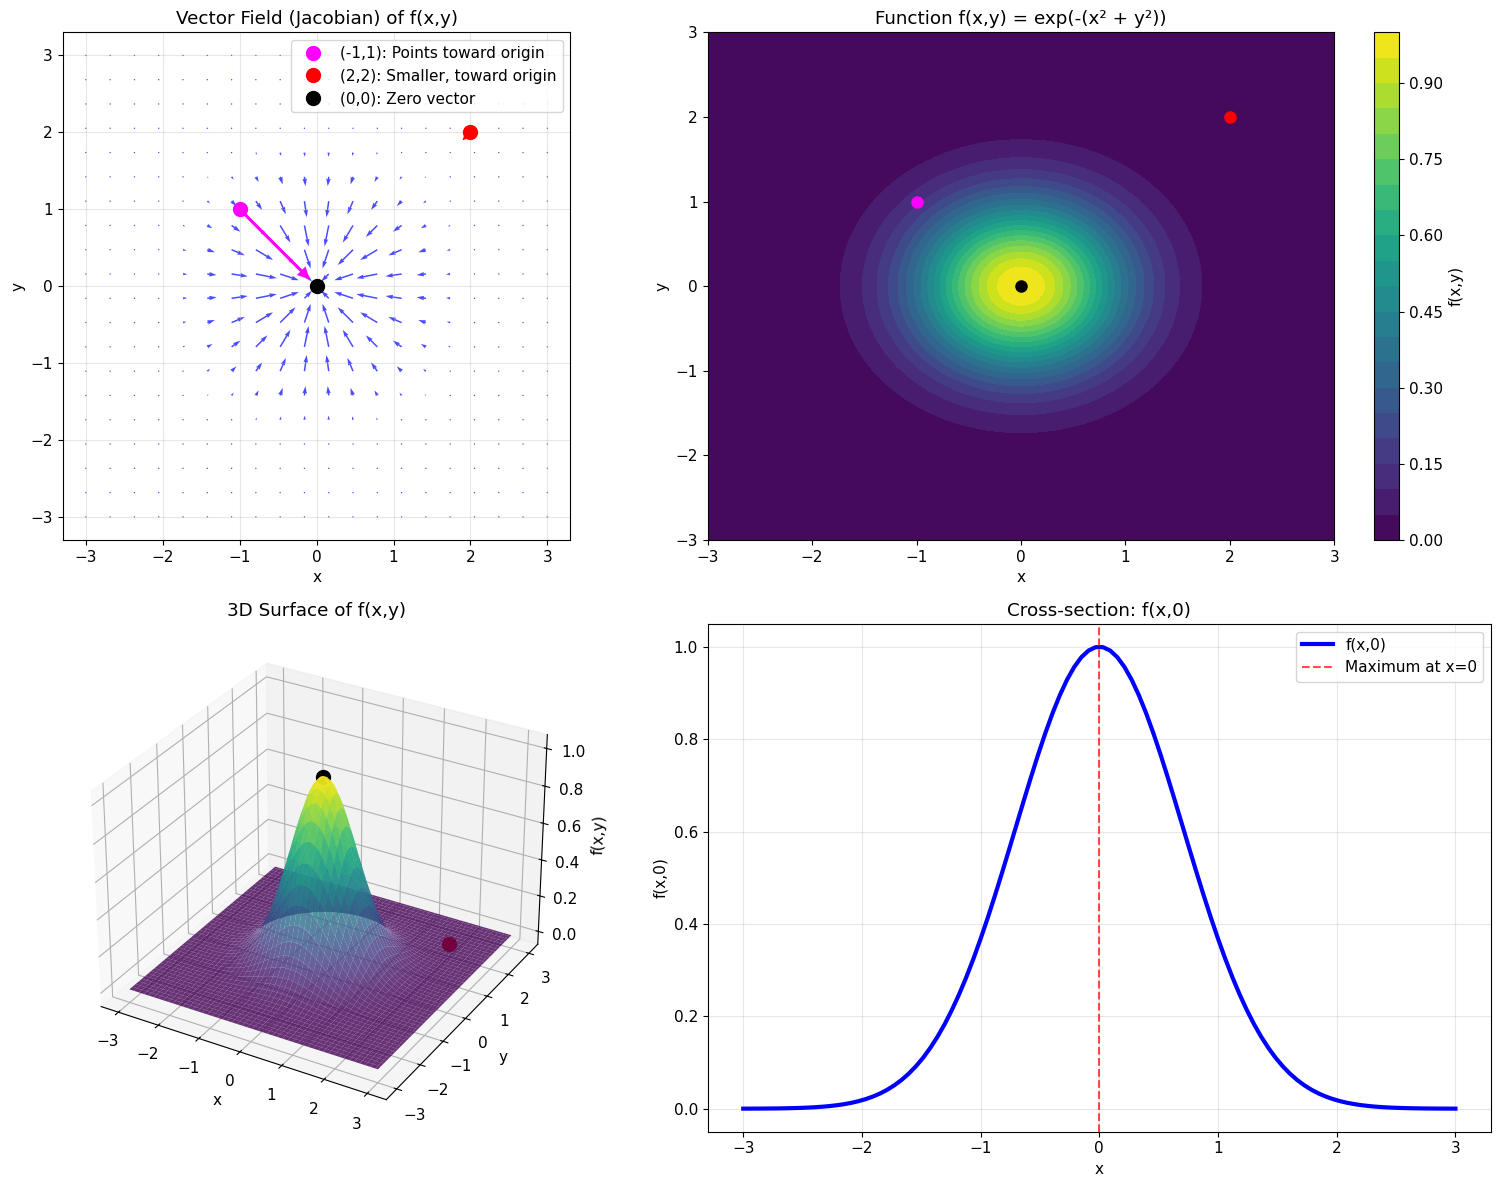

Interpretation of the Visualizations:
Vector Field (top-left): All arrows point toward the origin
Contour Plot (top-right): Brightest at origin, darker away from center
3D Surface (bottom-left): Clear maximum at origin - it's a 'hill'
Cross-section (bottom-right): Confirms the maximum at x=0

Conclusion: The zero Jacobian at origin indicates a MAXIMUM!


In [3]:
# Create comprehensive visualization of the function and its vector field
fig = plt.figure(figsize=(16, 12))

# Create meshgrid for plotting
x = np.linspace(-3, 3, 20)
y = np.linspace(-3, 3, 20)
X, Y = np.meshgrid(x, y)
Z = f(X, Y)

# Compute Jacobian vector field
JX = -2 * X * Z
JY = -2 * Y * Z

# Plot 1: Vector field with specific points highlighted
ax1 = fig.add_subplot(2, 2, 1)
ax1.quiver(X, Y, JX, JY, alpha=0.7, scale=20, color='blue')

# Highlight the specific points from the transcript
points = [(-1, 1), (2, 2), (0, 0)]
colors = ['magenta', 'red', 'black']
labels = ['(-1,1): Points toward origin', '(2,2): Smaller, toward origin', '(0,0): Zero vector']

for (px, py), color, label in zip(points, colors, labels):
    ax1.plot(px, py, 'o', color=color, markersize=10, label=label)
    if px != 0 or py != 0:  # Don't draw arrow for origin
        jac = jacobian_f(px, py)
        ax1.arrow(px, py, jac[0]*3, jac[1]*3, head_width=0.1, head_length=0.1, 
                 fc=color, ec=color, linewidth=2)

ax1.set_title('Vector Field (Jacobian) of f(x,y)')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.grid(True, alpha=0.3)
ax1.legend()
ax1.set_aspect('equal')

# Plot 2: Contour plot (color map) of the function
ax2 = fig.add_subplot(2, 2, 2)
x_fine = np.linspace(-3, 3, 100)
y_fine = np.linspace(-3, 3, 100)
X_fine, Y_fine = np.meshgrid(x_fine, y_fine)
Z_fine = f(X_fine, Y_fine)

contour = ax2.contourf(X_fine, Y_fine, Z_fine, levels=20, cmap='viridis')
plt.colorbar(contour, ax=ax2, label='f(x,y)')

# Overlay the same points
for (px, py), color in zip(points, colors):
    ax2.plot(px, py, 'o', color=color, markersize=8)

ax2.set_title('Function f(x,y) = exp(-(x² + y²))')
ax2.set_xlabel('x')
ax2.set_ylabel('y')

# Plot 3: 3D surface plot
ax3 = fig.add_subplot(2, 2, 3, projection='3d')
surf = ax3.plot_surface(X_fine, Y_fine, Z_fine, cmap='viridis', alpha=0.8)

# Mark the specific points in 3D
for (px, py), color in zip(points, colors):
    ax3.scatter(px, py, f(px, py), color=color, s=100)

ax3.set_title('3D Surface of f(x,y)')
ax3.set_xlabel('x')
ax3.set_ylabel('y')
ax3.set_zlabel('f(x,y)')

# Plot 4: Cross-section showing the maximum
ax4 = fig.add_subplot(2, 2, 4)
x_line = np.linspace(-3, 3, 100)
y_line = np.zeros_like(x_line)  # Cross-section along x-axis
z_line = f(x_line, y_line)

ax4.plot(x_line, z_line, 'b-', linewidth=3, label='f(x,0)')
ax4.axvline(x=0, color='red', linestyle='--', alpha=0.7, label='Maximum at x=0')
ax4.set_title('Cross-section: f(x,0)')
ax4.set_xlabel('x')
ax4.set_ylabel('f(x,0)')
ax4.grid(True, alpha=0.3)
ax4.legend()

plt.tight_layout()
plt.show()

print("Interpretation of the Visualizations:")
print("="*50)
print("Vector Field (top-left): All arrows point toward the origin")
print("Contour Plot (top-right): Brightest at origin, darker away from center")
print("3D Surface (bottom-left): Clear maximum at origin - it's a 'hill'")
print("Cross-section (bottom-right): Confirms the maximum at x=0")
print("\nConclusion: The zero Jacobian at origin indicates a MAXIMUM!")

## Part 2: Jacobian Matrices for Vector-Valued Functions

### Moving to Vector Outputs

Now let's consider functions that take a vector as input AND give a vector as output. This is where **Jacobian matrices** become essential.

### Example: Linear Transformation

Consider these two functions:
- $u(x, y) = x + 2y$
- $v(x, y) = 3y - 2x$

We can think of this as a transformation from $(x, y)$ space to $(u, v)$ space:

$$\begin{bmatrix} u \\ v \end{bmatrix} = \begin{bmatrix} x + 2y \\ 3y - 2x \end{bmatrix}$$

### Building the Jacobian Matrix

Instead of separate Jacobian vectors for $u$ and $v$, we stack them into a matrix:

$$J = \begin{bmatrix} \frac{\partial u}{\partial x} & \frac{\partial u}{\partial y} \\ \frac{\partial v}{\partial x} & \frac{\partial v}{\partial y} \end{bmatrix}$$

### Key Insight
**The Jacobian matrix is the linear transformation matrix that best approximates our function locally.**

In [4]:
# Define the vector-valued functions from the transcript
def u(x, y):
    """u(x,y) = x + 2y"""
    return x + 2*y

def v(x, y):
    """v(x,y) = 3y - 2x"""
    return 3*y - 2*x

def transform(x, y):
    """Complete transformation (x,y) -> (u,v)"""
    return np.array([u(x, y), v(x, y)])

# Compute the Jacobian matrix
print("Computing the Jacobian Matrix:")
print("="*40)
print("For u(x,y) = x + 2y:")
print("  ∂u/∂x = 1")
print("  ∂u/∂y = 2")
print()
print("For v(x,y) = 3y - 2x:")
print("  ∂v/∂x = -2") 
print("  ∂v/∂y = 3")
print()

# The Jacobian matrix (constant for linear functions)
J = np.array([[ 1,  2],
              [-2,  3]])

print("Jacobian matrix J:")
print(J)
print()
print("Key observations:")
print("• No variables in the matrix - it's constant everywhere")
print("• This happens because both u and v are LINEAR functions")
print("• J represents the linear transformation from (x,y) to (u,v)")
print()

# Test the transformation with the example from the transcript
test_point = np.array([2, 3])
print(f"Testing with point {test_point}:")
print()

# Method 1: Direct calculation
u_direct = u(test_point[0], test_point[1])
v_direct = v(test_point[0], test_point[1])
result_direct = np.array([u_direct, v_direct])
print(f"Direct calculation: u = {u_direct}, v = {v_direct}")
print(f"Result vector: {result_direct}")
print()

# Method 2: Matrix multiplication
result_matrix = J @ test_point
print(f"Matrix multiplication J @ [2,3]: {result_matrix}")
print()

# Verify they're the same
print(f"Results match: {np.allclose(result_direct, result_matrix)}")
print()

# Show the calculation step by step
print("Step-by-step matrix multiplication:")
print(f"[1  2] @ [2] = [1×2 + 2×3] = [2 + 6] = [ 8]")
print(f"[-2 3]   [3]   [-2×2 + 3×3]   [-4 + 9]   [ 5]")
print(f"                              = [{result_matrix[0]}, {result_matrix[1]}]")

Computing the Jacobian Matrix:
For u(x,y) = x + 2y:
  ∂u/∂x = 1
  ∂u/∂y = 2

For v(x,y) = 3y - 2x:
  ∂v/∂x = -2
  ∂v/∂y = 3

Jacobian matrix J:
[[ 1  2]
 [-2  3]]

Key observations:
• No variables in the matrix - it's constant everywhere
• This happens because both u and v are LINEAR functions
• J represents the linear transformation from (x,y) to (u,v)

Testing with point [2 3]:

Direct calculation: u = 8, v = 5
Result vector: [8 5]

Matrix multiplication J @ [2,3]: [8 5]

Results match: True

Step-by-step matrix multiplication:
[1  2] @ [2] = [1×2 + 2×3] = [2 + 6] = [ 8]
[-2 3]   [3]   [-2×2 + 3×3]   [-4 + 9]   [ 5]
                              = [8, 5]


Point 1: (0, 0) → (0, 0)
Point 2: (1, 0) → (1, -2)
Point 3: (0, 1) → (2, 3)
Point 4: (1, 1) → (3, 1)
Point 5: (2, 3) → (8, 5)


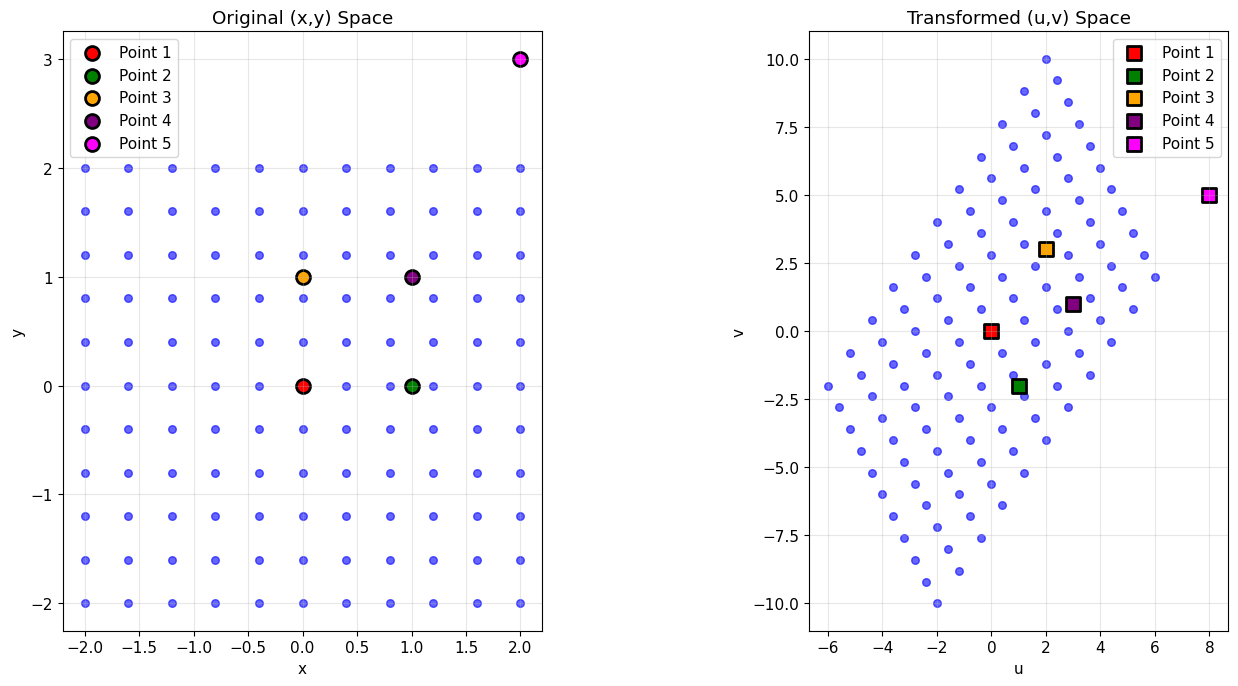


How the transformation affects unit vectors:
Unit vector [1,0] → [ 1 -2]
Unit vector [0,1] → [2 3]

These are exactly the COLUMNS of the Jacobian matrix!
• First column of J = where [1,0] goes
• Second column of J = where [0,1] goes

This shows how the Jacobian matrix encodes the linear transformation.


In [5]:
# Visualize how the linear transformation affects different regions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))

# Create a grid of points in (x,y) space
x_pts = np.linspace(-2, 2, 11)
y_pts = np.linspace(-2, 2, 11)
X_grid, Y_grid = np.meshgrid(x_pts, y_pts)

# Transform all points to (u,v) space
U_grid = u(X_grid, Y_grid)
V_grid = v(X_grid, Y_grid)

# Plot original (x,y) space
ax1.scatter(X_grid, Y_grid, c='blue', alpha=0.6, s=30)
ax1.set_title('Original (x,y) Space')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.grid(True, alpha=0.3)
ax1.set_aspect('equal')

# Highlight some specific points and their paths
special_points_xy = np.array([[0, 0], [1, 0], [0, 1], [1, 1], [2, 3]])
colors = ['red', 'green', 'orange', 'purple', 'magenta']

for i, (point, color) in enumerate(zip(special_points_xy, colors)):
    ax1.scatter(point[0], point[1], c=color, s=100, marker='o', 
               edgecolors='black', linewidth=2, label=f'Point {i+1}')

ax1.legend()

# Plot transformed (u,v) space  
ax2.scatter(U_grid, V_grid, c='blue', alpha=0.6, s=30)
ax2.set_title('Transformed (u,v) Space')
ax2.set_xlabel('u')
ax2.set_ylabel('v')
ax2.grid(True, alpha=0.3)
ax2.set_aspect('equal')

# Show where the special points end up
for i, (point, color) in enumerate(zip(special_points_xy, colors)):
    transformed = J @ point
    ax2.scatter(transformed[0], transformed[1], c=color, s=100, marker='s',
               edgecolors='black', linewidth=2, label=f'Point {i+1}')
    
    # Print the transformation
    print(f"Point {i+1}: ({point[0]}, {point[1]}) → ({transformed[0]}, {transformed[1]})")

ax2.legend()

plt.tight_layout()
plt.show()

# Show how the transformation affects basic vectors
print("\nHow the transformation affects unit vectors:")
print("="*50)
e1 = np.array([1, 0])  # Unit vector in x direction
e2 = np.array([0, 1])  # Unit vector in y direction

transformed_e1 = J @ e1
transformed_e2 = J @ e2

print(f"Unit vector [1,0] → {transformed_e1}")
print(f"Unit vector [0,1] → {transformed_e2}")
print()
print("These are exactly the COLUMNS of the Jacobian matrix!")
print("• First column of J = where [1,0] goes")
print("• Second column of J = where [0,1] goes")
print()
print("This shows how the Jacobian matrix encodes the linear transformation.")

## Part 3: Nonlinear Functions and Local Linear Approximation

### Beyond Linear Functions

Most real-world functions are **nonlinear** and much more complex than our linear example. However, the key insight is:

> **Even nonlinear functions can be approximated locally by linear functions if they are smooth.**

### The Local Approximation Principle

For smooth nonlinear functions:
1. **Zoom in close enough** to any point
2. The function looks approximately **linear** in that small region
3. The **Jacobian matrix** at that point gives us the best linear approximation
4. By adding up contributions from all local regions, we can analyze global behavior

### Applications

This principle allows us to:
- **Calculate area/volume changes** under nonlinear transformations
- **Understand coordinate system changes** (like Cartesian ↔ Polar)
- **Optimize functions** using local linear information

## Part 4: Coordinate Transformations - Cartesian to Polar

### The Classic Example

One of the most important applications is transforming between **Cartesian** $(x, y)$ and **polar** $(r, \theta)$ coordinates.

### The Transformation Equations

From polar to Cartesian coordinates:
- $x = r \cos(\theta)$
- $y = r \sin(\theta)$

### Building the Jacobian Matrix

For the transformation $(r, \theta) \rightarrow (x, y)$:

$$J = \begin{bmatrix} \frac{\partial x}{\partial r} & \frac{\partial x}{\partial \theta} \\ \frac{\partial y}{\partial r} & \frac{\partial y}{\partial \theta} \end{bmatrix} = \begin{bmatrix} \cos(\theta) & -r\sin(\theta) \\ \sin(\theta) & r\cos(\theta) \end{bmatrix}$$

### The Jacobian Determinant

$$\det(J) = \cos(\theta) \cdot r\cos(\theta) - (-r\sin(\theta)) \cdot \sin(\theta) = r\cos^2(\theta) + r\sin^2(\theta) = r$$

### Key Insight

The determinant is simply $r$! This tells us:
- **As we move away from origin** ($r$ increases), **small regions scale by factor $r$**
- **Areas grow proportionally to distance from origin**
- This is why we need the "$r$" factor in polar integration: $dA = r \, dr \, d\theta$

In [6]:
# Implement polar to Cartesian coordinate transformation
def polar_to_cartesian(r, theta):
    """Transform (r, theta) to (x, y)"""
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    return x, y

def jacobian_polar(r, theta):
    """Jacobian matrix for polar to Cartesian transformation"""
    return np.array([[np.cos(theta), -r * np.sin(theta)],
                     [np.sin(theta),  r * np.cos(theta)]])

def jacobian_determinant_polar(r, theta):
    """Determinant of Jacobian matrix"""
    return r  # This is the key result!

# Demonstrate the calculation
print("Polar to Cartesian Coordinate Transformation")
print("="*50)
print("Transformation equations:")
print("  x = r cos(θ)")
print("  y = r sin(θ)")
print()

print("Jacobian matrix:")
print("  J = [cos(θ)   -r sin(θ)]")
print("      [sin(θ)    r cos(θ)]")
print()

print("Jacobian determinant:")
print("  det(J) = cos(θ) · r cos(θ) - (-r sin(θ)) · sin(θ)")
print("         = r cos²(θ) + r sin²(θ)")
print("         = r(cos²(θ) + sin²(θ))")
print("         = r · 1 = r")
print()

# Test with specific values
test_points = [(1, 0), (2, np.pi/4), (3, np.pi/2), (1, np.pi)]
print("Testing at specific points:")
print("-" * 30)

for r, theta in test_points:
    x, y = polar_to_cartesian(r, theta)
    J = jacobian_polar(r, theta)
    det_J = jacobian_determinant_polar(r, theta)
    
    print(f"(r={r}, θ={theta:.3f}) → (x={x:.3f}, y={y:.3f})")
    print(f"  Jacobian determinant = {det_J}")
    print(f"  Area scaling factor = {det_J}")
    print()

Polar to Cartesian Coordinate Transformation
Transformation equations:
  x = r cos(θ)
  y = r sin(θ)

Jacobian matrix:
  J = [cos(θ)   -r sin(θ)]
      [sin(θ)    r cos(θ)]

Jacobian determinant:
  det(J) = cos(θ) · r cos(θ) - (-r sin(θ)) · sin(θ)
         = r cos²(θ) + r sin²(θ)
         = r(cos²(θ) + sin²(θ))
         = r · 1 = r

Testing at specific points:
------------------------------
(r=1, θ=0.000) → (x=1.000, y=0.000)
  Jacobian determinant = 1
  Area scaling factor = 1

(r=2, θ=0.785) → (x=1.414, y=1.414)
  Jacobian determinant = 2
  Area scaling factor = 2

(r=3, θ=1.571) → (x=0.000, y=3.000)
  Jacobian determinant = 3
  Area scaling factor = 3

(r=1, θ=3.142) → (x=-1.000, y=0.000)
  Jacobian determinant = 1
  Area scaling factor = 1



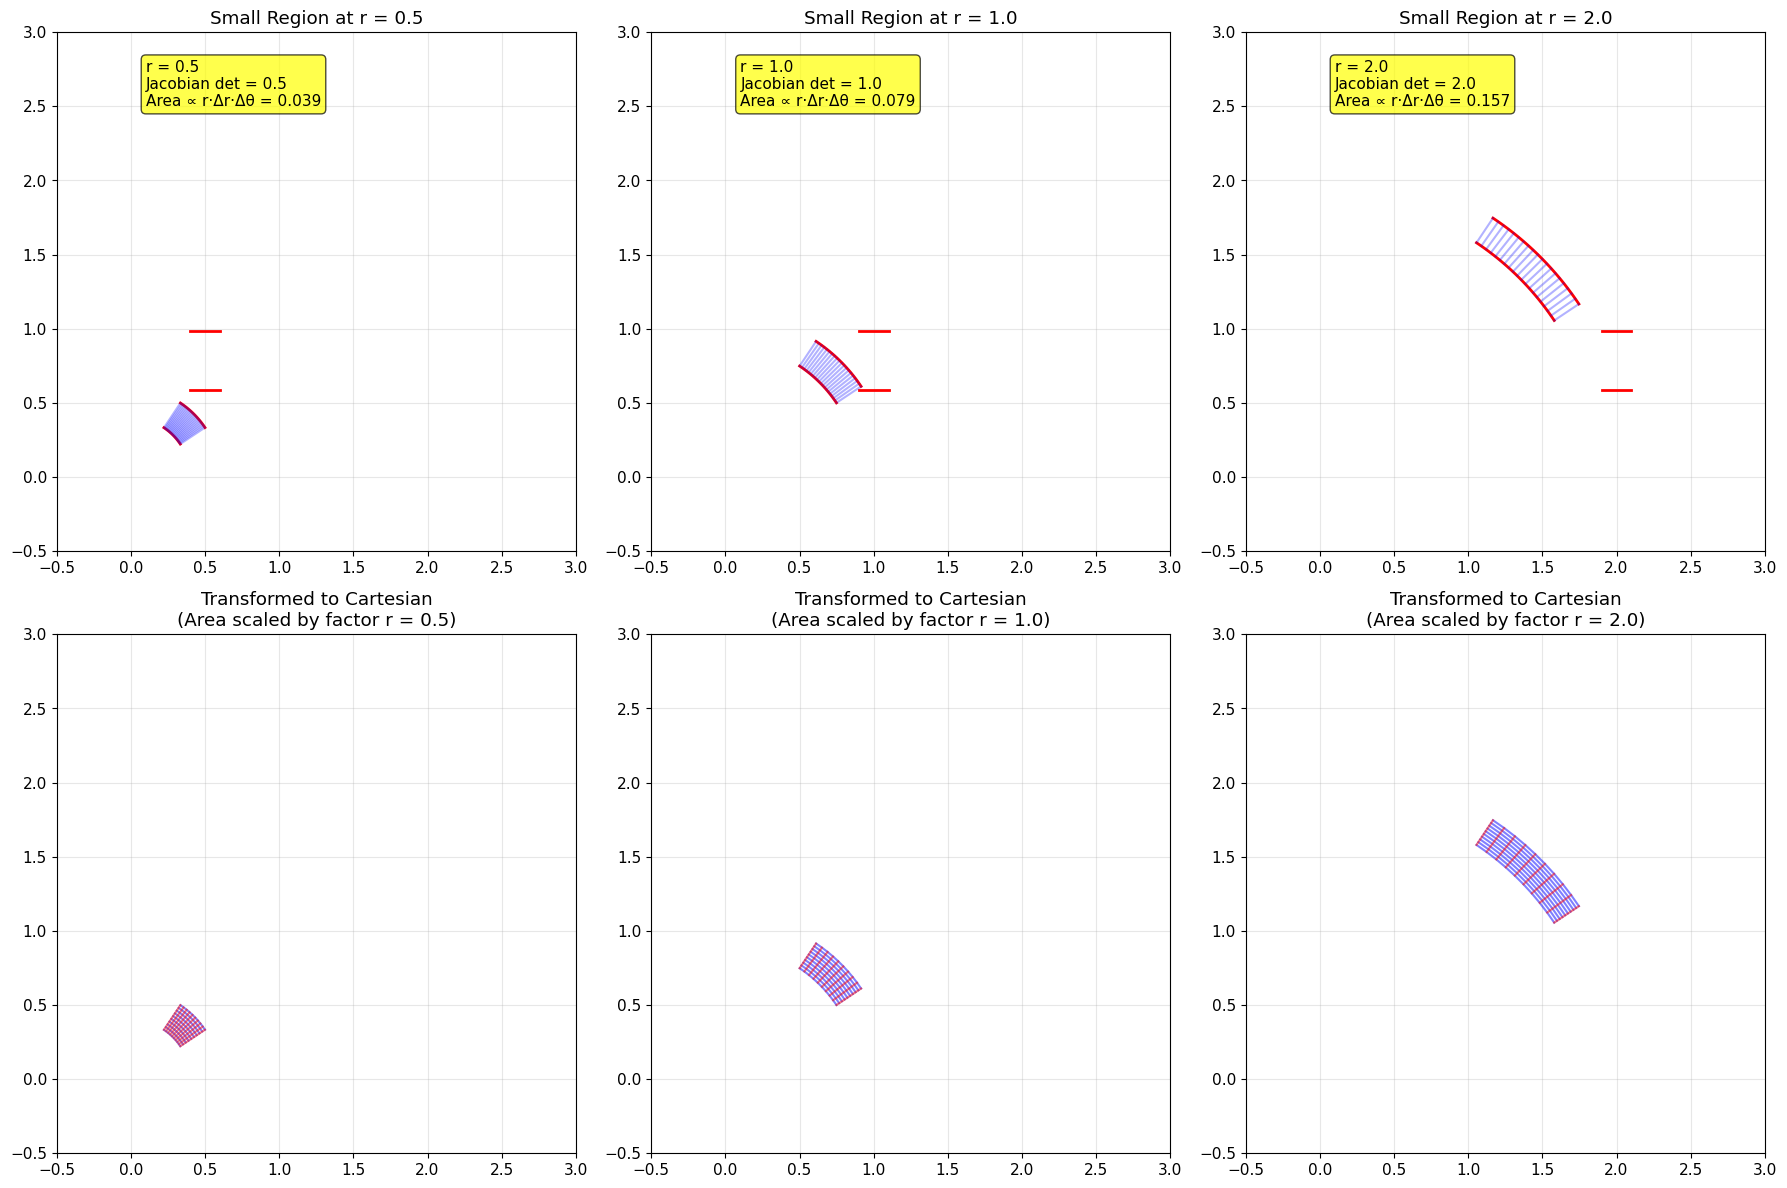

Key Observations from the Visualization:
• As r increases, the same Δr×Δθ region gets LARGER in Cartesian space
• The scaling factor is exactly r (the Jacobian determinant)
• This is why polar integrals need the 'r' factor: ∫∫ f(r,θ) r dr dθ
• The 'r' accounts for how area elements stretch as we move away from origin

Physical Interpretation:
• Think of a pizza slice: outer edge is longer than inner edge
• Same angular width Δθ covers more 'actual area' at larger radius r
• The Jacobian determinant quantifies this stretching effect


In [7]:
# Create visualization showing how area scales with radius
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Parameters for demonstration
radii = [0.5, 1.0, 2.0]  # Different distances from origin
theta_center = np.pi/4   # 45 degrees
delta_r = 0.2
delta_theta = np.pi/8

# Create the "little animation" showing area scaling
for i, r in enumerate(radii):
    # Original small region in polar coordinates
    ax_polar = axes[0, i]
    
    # Draw the small region in polar coordinates
    theta_range = np.linspace(theta_center - delta_theta/2, theta_center + delta_theta/2, 100)
    r_inner = r - delta_r/2
    r_outer = r + delta_r/2
    
    # Plot the radial lines
    ax_polar.plot([r_inner, r_outer], [theta_center - delta_theta/2, theta_center - delta_theta/2], 'r-', linewidth=2)
    ax_polar.plot([r_inner, r_outer], [theta_center + delta_theta/2, theta_center + delta_theta/2], 'r-', linewidth=2)
    
    # Plot the circular arcs
    theta_fine = np.linspace(theta_center - delta_theta/2, theta_center + delta_theta/2, 50)
    x_inner = r_inner * np.cos(theta_fine)
    y_inner = r_inner * np.sin(theta_fine)
    x_outer = r_outer * np.cos(theta_fine)
    y_outer = r_outer * np.sin(theta_fine)
    
    ax_polar.plot(x_inner, y_inner, 'r-', linewidth=2)
    ax_polar.plot(x_outer, y_outer, 'r-', linewidth=2)
    
    # Fill the region
    theta_fill = np.linspace(theta_center - delta_theta/2, theta_center + delta_theta/2, 20)
    for t in theta_fill:
        ax_polar.plot([r_inner * np.cos(t), r_outer * np.cos(t)], 
                     [r_inner * np.sin(t), r_outer * np.sin(t)], 'b-', alpha=0.3)
    
    ax_polar.set_xlim(-0.5, 3)
    ax_polar.set_ylim(-0.5, 3)
    ax_polar.set_aspect('equal')
    ax_polar.grid(True, alpha=0.3)
    ax_polar.set_title(f'Small Region at r = {r}')
    
    # Calculate and display areas
    area_polar = r * delta_r * delta_theta  # Approximate area in polar
    jacobian_det = r
    
    ax_polar.text(0.1, 2.5, f'r = {r}\nJacobian det = {jacobian_det}\nArea ∝ r·Δr·Δθ = {area_polar:.3f}', 
                 bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7))
    
    # Transformed region in Cartesian coordinates
    ax_cart = axes[1, i]
    
    # Create a grid of points in the small polar region
    r_pts = np.linspace(r_inner, r_outer, 10)
    theta_pts = np.linspace(theta_center - delta_theta/2, theta_center + delta_theta/2, 10)
    
    # Transform to Cartesian and plot
    for r_pt in r_pts:
        x_line = r_pt * np.cos(theta_pts)
        y_line = r_pt * np.sin(theta_pts)
        ax_cart.plot(x_line, y_line, 'b-', alpha=0.5)
    
    for theta_pt in theta_pts:
        x_line = r_pts * np.cos(theta_pt)
        y_line = r_pts * np.sin(theta_pt)
        ax_cart.plot(x_line, y_line, 'r-', alpha=0.5)
    
    ax_cart.set_xlim(-0.5, 3)
    ax_cart.set_ylim(-0.5, 3)
    ax_cart.set_aspect('equal')
    ax_cart.grid(True, alpha=0.3)
    ax_cart.set_title(f'Transformed to Cartesian\n(Area scaled by factor r = {r})')

plt.tight_layout()
plt.show()

print("Key Observations from the Visualization:")
print("="*50)
print("• As r increases, the same Δr×Δθ region gets LARGER in Cartesian space")
print("• The scaling factor is exactly r (the Jacobian determinant)")
print("• This is why polar integrals need the 'r' factor: ∫∫ f(r,θ) r dr dθ")
print("• The 'r' accounts for how area elements stretch as we move away from origin")
print()
print("Physical Interpretation:")
print("• Think of a pizza slice: outer edge is longer than inner edge")
print("• Same angular width Δθ covers more 'actual area' at larger radius r")
print("• The Jacobian determinant quantifies this stretching effect")

## Summary: Key Concepts and Applications

### What We've Learned

✅ **Jacobian Vectors (Gradients)** - For scalar functions, show direction of steepest increase  
✅ **Vector Fields** - Visualize how gradients point throughout space  
✅ **Critical Points** - Zero Jacobian indicates maxima, minima, or saddle points  
✅ **Jacobian Matrices** - For vector-valued functions, encode local linear transformations  
✅ **Linear vs Nonlinear** - Linear functions have constant Jacobians, nonlinear vary by location  
✅ **Coordinate Transformations** - Jacobian determinant shows area/volume scaling  

### The Big Picture

The Jacobian provides two crucial pieces of information:

1. **Direction**: Where is the function changing most rapidly?
2. **Magnitude**: How much is the function changing?

For transformations, the Jacobian determinant tells us **how much areas/volumes get stretched or compressed**.

### Real-World Applications

**Engineering & Physics:**
- Fluid flow analysis (velocity fields)
- Heat transfer (temperature gradients)  
- Electromagnetic fields
- Stress analysis in materials

**Computer Graphics:**
- 3D transformations and projections
- Image warping and morphing
- Animation and deformation

**Machine Learning:**
- Gradient descent optimization
- Backpropagation in neural networks
- Change of variables in probability

**Mathematics:**
- Change of variables in integration
- Coordinate system transformations
- Differential equations

### The Power of Local Linear Approximation

Even when functions are highly nonlinear and complex, the Jacobian gives us a way to:
- **Understand local behavior** through linear approximation
- **Calculate global effects** by integrating local contributions
- **Optimize** by following gradient directions
- **Transform coordinates** while preserving geometric relationships

## Practice Exercises

### Exercise 1: Computing Jacobian Vectors
For the function $f(x, y) = x^2 + y^2$:

a) Compute the Jacobian vector $\nabla f$  
b) Evaluate it at points $(1, 1)$, $(0, 0)$, and $(-2, 1)$  
c) What type of critical point is at the origin?  

### Exercise 2: Jacobian Matrices
For the transformation:
- $u(x, y) = 2x - y$
- $v(x, y) = x + 3y$

a) Find the Jacobian matrix  
b) Is this transformation linear or nonlinear?  
c) Apply it to the point $(1, -2)$  

### Exercise 3: Coordinate Transformations
For cylindrical coordinates: $x = r\cos(\theta)$, $y = r\sin(\theta)$, $z = z$

a) Find the Jacobian matrix for the transformation $(r, \theta, z) \rightarrow (x, y, z)$  
b) Compute the Jacobian determinant  
c) What does this tell us about volume elements in cylindrical coordinates?  

### Exercise 4: Interpretation
Look at these Jacobian determinant values and explain what they mean:

a) $\det(J) = 2$ - Areas are _____ by the transformation  
b) $\det(J) = 0.5$ - Areas are _____ by the transformation  
c) $\det(J) = 0$ - The transformation is _____  
d) $\det(J) = -1$ - Areas are _____ and orientation is _____

SOLUTIONS TO PRACTICE EXERCISES

Exercise 1: f(x,y) = x² + y²
------------------------------
a) Jacobian vector ∇f = [∂f/∂x, ∂f/∂y] = [2x, 2y]

b) Evaluations:
   At (1, 1): ∇f = [2, 2]
   At (0, 0): ∇f = [0, 0]
   At (-2, 1): ∇f = [-4, 2]

c) At origin: ∇f = [0, 0] (zero vector)
   Since f(x,y) = x² + y² ≥ 0 and f(0,0) = 0, origin is a MINIMUM


Exercise 2: u = 2x - y, v = x + 3y
------------------------------
a) Jacobian matrix:
   J = [∂u/∂x  ∂u/∂y] = [2  -1]
       [∂v/∂x  ∂v/∂y]   [1   3]

b) LINEAR transformation (all partial derivatives are constants)

c) At point [ 1 -2]: J @ [1, -2] = [ 4 -5]
   Check: u = 2(1) - (-2) = 4, v = 1 + 3(-2) = -5 ✓


Exercise 3: Cylindrical coordinates
------------------------------
a) Jacobian matrix (r,θ,z) → (x,y,z):
   J = [cos(θ)  -r sin(θ)  0]
       [sin(θ)   r cos(θ)  0]
       [  0         0      1]

b) Jacobian determinant:
   det(J) = cos(θ) · [r cos(θ) · 1 - 0 · 0] - (-r sin(θ)) · [sin(θ) · 1 - 0 · 0] + 0
          = r cos²(θ) + r sin²(

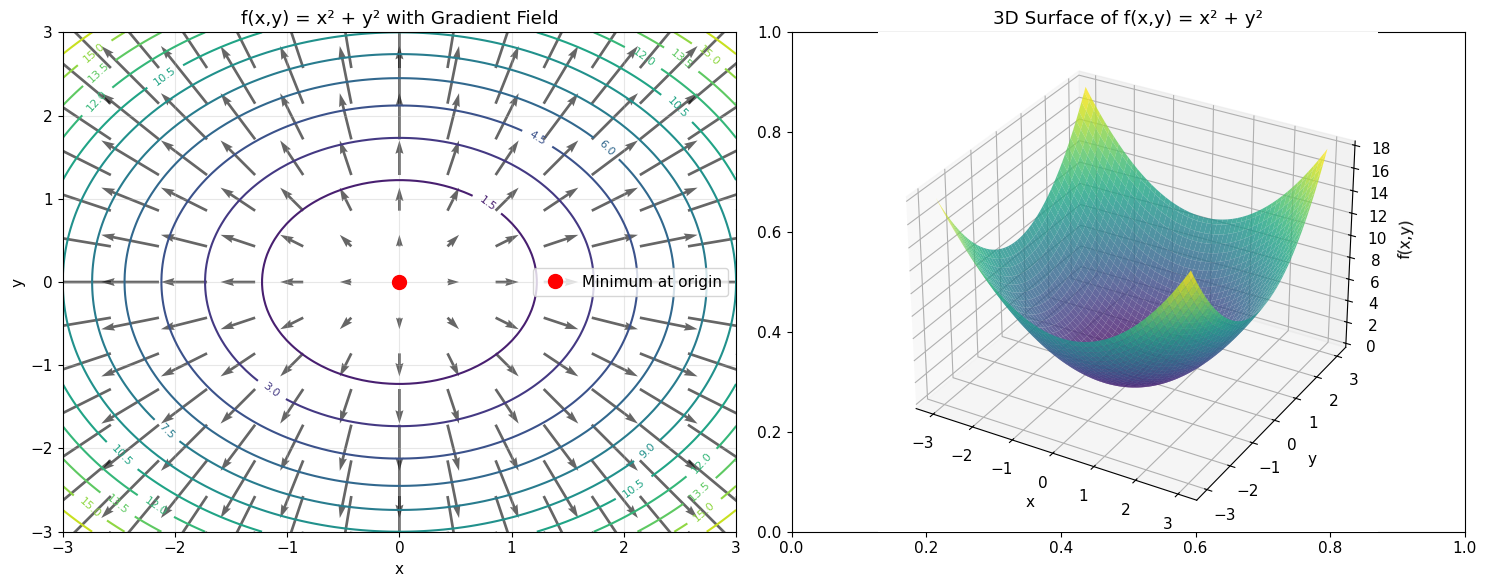

In [8]:
# Solutions to Practice Exercises
print("SOLUTIONS TO PRACTICE EXERCISES")
print("="*50)

print("\nExercise 1: f(x,y) = x² + y²")
print("-" * 30)
print("a) Jacobian vector ∇f = [∂f/∂x, ∂f/∂y] = [2x, 2y]")
print()
print("b) Evaluations:")
points = [(1, 1), (0, 0), (-2, 1)]
for x, y in points:
    grad = np.array([2*x, 2*y])
    print(f"   At ({x}, {y}): ∇f = [{grad[0]}, {grad[1]}]")
print()
print("c) At origin: ∇f = [0, 0] (zero vector)")
print("   Since f(x,y) = x² + y² ≥ 0 and f(0,0) = 0, origin is a MINIMUM")

print("\n" + "="*50)

print("\nExercise 2: u = 2x - y, v = x + 3y")
print("-" * 30)
J2 = np.array([[2, -1], [1, 3]])
print("a) Jacobian matrix:")
print(f"   J = [∂u/∂x  ∂u/∂y] = [2  -1]")
print(f"       [∂v/∂x  ∂v/∂y]   [1   3]")
print()
print("b) LINEAR transformation (all partial derivatives are constants)")
print()
test_point = np.array([1, -2])
result = J2 @ test_point
print(f"c) At point {test_point}: J @ [1, -2] = {result}")
print(f"   Check: u = 2(1) - (-2) = 4, v = 1 + 3(-2) = -5 ✓")

print("\n" + "="*50)

print("\nExercise 3: Cylindrical coordinates")
print("-" * 30)
print("a) Jacobian matrix (r,θ,z) → (x,y,z):")
print("   J = [cos(θ)  -r sin(θ)  0]")
print("       [sin(θ)   r cos(θ)  0]")
print("       [  0         0      1]")
print()
print("b) Jacobian determinant:")
print("   det(J) = cos(θ) · [r cos(θ) · 1 - 0 · 0] - (-r sin(θ)) · [sin(θ) · 1 - 0 · 0] + 0")
print("          = r cos²(θ) + r sin²(θ) = r")
print()
print("c) Volume elements: dV = r dr dθ dz")
print("   The 'r' factor accounts for increasing circumference at larger radius")

print("\n" + "="*50)

print("\nExercise 4: Interpreting Jacobian determinants")
print("-" * 30)
print("a) det(J) = 2    → Areas are DOUBLED by the transformation")
print("b) det(J) = 0.5  → Areas are HALVED by the transformation") 
print("c) det(J) = 0    → The transformation is DEGENERATE (collapses to lower dimension)")
print("d) det(J) = -1   → Areas are PRESERVED and orientation is REVERSED")

print("\n" + "="*50)
print("\nKey Insights:")
print("• Jacobian vector shows direction and rate of change")
print("• Jacobian matrix encodes local linear transformation")
print("• Jacobian determinant shows area/volume scaling")
print("• Sign of determinant indicates orientation preservation/reversal")

# Visualize Exercise 1 solution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot the function f(x,y) = x² + y²
x = np.linspace(-3, 3, 100)
y = np.linspace(-3, 3, 100)
X, Y = np.meshgrid(x, y)
Z = X**2 + Y**2

# Contour plot
contour = ax1.contour(X, Y, Z, levels=15)
ax1.clabel(contour, inline=True, fontsize=8)

# Plot gradient field
x_sparse = np.linspace(-3, 3, 15)
y_sparse = np.linspace(-3, 3, 15)
X_sparse, Y_sparse = np.meshgrid(x_sparse, y_sparse)
GX = 2 * X_sparse
GY = 2 * Y_sparse

ax1.quiver(X_sparse, Y_sparse, GX, GY, alpha=0.6, scale=50)
ax1.plot(0, 0, 'ro', markersize=10, label='Minimum at origin')
ax1.set_title('f(x,y) = x² + y² with Gradient Field')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 3D surface
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
surf = ax2.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8)
ax2.set_title('3D Surface of f(x,y) = x² + y²')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_zlabel('f(x,y)')

plt.tight_layout()
plt.show()